# 03 — Modélisation & Évaluation in-domain

Ce notebook couvre l'étape 2 du pipeline :
1. Entraînement des modèles classiques (LR, RF, XGBoost) avec TF-IDF + métadonnées
2. Fine-tuning DistilBERT sur Apple Silicon (MPS)
3. Évaluation in-domain : accuracy, F1, matrices de confusion
4. Interprétabilité : SHAP sur le meilleur modèle classique
5. Analyse des erreurs
6. Comparaison finale des 4 modèles

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import shap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import shap

from src.preprocessing import load_liar, preprocess_liar
from src.features import TfidfFeatures, CombinedFeatures, get_X_y, META_COLS
from src.train import (
    train_logistic_regression, train_random_forest, train_xgboost,
    train_bert, save_classical_model
)
from src.evaluate import (
    evaluate_model, compare_models, plot_confusion_matrix,
    explain_with_shap, analyze_errors, save_results
)

print("Imports OK")

Imports OK


## 1. Chargement des données préprocessées

In [2]:
# Option A : depuis les CSV sauvegardés dans 02_preprocessing.ipynb (recommandé)
train = pd.read_csv("data/processed/train_clean.csv")
valid = pd.read_csv("data/processed/valid_clean.csv")
test  = pd.read_csv("data/processed/test_clean.csv")

# Option B : si les CSV ne sont pas encore générés, relancer le preprocessing
# train_raw, valid_raw, test_raw = load_liar("data/raw")
# train = preprocess_liar(train_raw)
# valid = preprocess_liar(valid_raw)
# test  = preprocess_liar(test_raw)

print(f"Train : {len(train)} | Valid : {len(valid)} | Test : {len(test)}")
print(f"Colonnes : {train.columns.tolist()}")

Train : 10240 | Valid : 1284 | Test : 1267
Colonnes : ['id', 'statement', 'statement_clean', 'label', 'label_3class', 'label_encoded', 'speaker', 'party', 'subject', 'credibility_score', 'lie_rate', 'history_total', 'is_politician']


## 2. Construction des features

In [3]:
# TF-IDF + métadonnées (modèle principal pour les classiques)
tfidf = TfidfFeatures(max_features=20_000, ngram_range=(1, 2))
combined = CombinedFeatures(text_features=tfidf, scale_meta=True)

# Fit sur le train uniquement — IMPORTANT
tfidf.fit_transform(train["statement_clean"])
X_train, y_train = get_X_y(train, combined, fit=True)
X_valid, y_valid = get_X_y(valid, combined, fit=False)
X_test,  y_test  = get_X_y(test,  combined, fit=False)

feature_names = combined.get_feature_names()
print(f"\nNombre de features : {X_train.shape[1]}")
print(f"Dont métadonnées   : {len(META_COLS)} ({META_COLS})")

TF-IDF fit — vocabulaire : 9049 features, 10240 documents
TF-IDF fit — vocabulaire : 9049 features, 10240 documents
X shape: (10240, 9053), y shape: (10240,), classes: (array([0, 1, 2]), array([2834, 3768, 3638]))
X shape: (1284, 9053), y shape: (1284,), classes: (array([0, 1, 2]), array([379, 485, 420]))
X shape: (1267, 9053), y shape: (1267,), classes: (array([0, 1, 2]), array([341, 477, 449]))

Nombre de features : 9053
Dont métadonnées   : 4 (['credibility_score', 'lie_rate', 'history_total', 'is_politician'])


## 3. Modèles classiques

On entraîne les 3 modèles sur le train set et on évalue immédiatement
sur le valid set pour détecter un éventuel sur-apprentissage.

In [4]:
# --- Logistic Regression ---
# NOTE: après modification de `src/train.py`, Jupyter peut garder l'ancienne version en mémoire.
# On force donc le reload du module pour prendre en compte les changements.
import importlib
import src.train as train_mod
importlib.reload(train_mod)

lr = train_mod.train_logistic_regression(X_train, y_train)
y_pred_lr_valid = lr.predict(X_valid)
results_lr = evaluate_model(y_valid, y_pred_lr_valid, "Logistic Regression (valid)")
save_classical_model(lr, "tfidf_logreg")

Entraînement Logistic Regression...
  LR — terminé

  Logistic Regression (valid)
  Accuracy    : 0.5670
  F1 macro    : 0.5711   ← métrique principale
  F1 weighted : 0.5662

  F1 par classe :
    fake       : 0.6520
    nuanced    : 0.5268
    real       : 0.5344

              precision    recall  f1-score   support

        fake       0.64      0.66      0.65       379
     nuanced       0.54      0.52      0.53       485
        real       0.53      0.54      0.53       420

    accuracy                           0.57      1284
   macro avg       0.57      0.57      0.57      1284
weighted avg       0.57      0.57      0.57      1284

  Sauvegardé -> models/tfidf_logreg.pkl


In [5]:
# --- Random Forest ---
rf = train_random_forest(X_train, y_train)
y_pred_rf_valid = rf.predict(X_valid)
results_rf = evaluate_model(y_valid, y_pred_rf_valid, "Random Forest (valid)")
save_classical_model(rf, "tfidf_rf")

Entraînement Random Forest...
  RF — terminé

  Random Forest (valid)
  Accuracy    : 0.5740
  F1 macro    : 0.5775   ← métrique principale
  F1 weighted : 0.5726

  F1 par classe :
    fake       : 0.6312
    nuanced    : 0.5142
    real       : 0.5873

              precision    recall  f1-score   support

        fake       0.64      0.63      0.63       379
     nuanced       0.55      0.49      0.51       485
        real       0.55      0.63      0.59       420

    accuracy                           0.57      1284
   macro avg       0.58      0.58      0.58      1284
weighted avg       0.57      0.57      0.57      1284

  Sauvegardé -> models/tfidf_rf.pkl


In [6]:
# --- XGBoost ---
xgb = train_xgboost(X_train, y_train)
# XGBoost nécessite dense
X_valid_dense = X_valid.toarray() if hasattr(X_valid, "toarray") else X_valid
y_pred_xgb_valid = xgb.predict(X_valid_dense)
results_xgb = evaluate_model(y_valid, y_pred_xgb_valid, "XGBoost (valid)")
save_classical_model(xgb, "tfidf_xgboost")

Entraînement XGBoost...
  XGBoost — terminé

  XGBoost (valid)
  Accuracy    : 0.5763
  F1 macro    : 0.5781   ← métrique principale
  F1 weighted : 0.5735

  F1 par classe :
    fake       : 0.6439
    nuanced    : 0.5304
    real       : 0.5599

              precision    recall  f1-score   support

        fake       0.60      0.70      0.64       379
     nuanced       0.57      0.49      0.53       485
        real       0.56      0.56      0.56       420

    accuracy                           0.58      1284
   macro avg       0.58      0.58      0.58      1284
weighted avg       0.58      0.58      0.57      1284

  Sauvegardé -> models/tfidf_xgboost.pkl


## 4. Évaluation finale sur le test set

On utilise le test set UNE SEULE FOIS, sur le meilleur modèle identifié
sur le valid set. Utiliser le test set pour choisir le modèle introduirait
un biais d'évaluation (data leakage).

In [7]:
# Identifier le meilleur modèle classique sur valid
valid_results = [results_lr, results_rf, results_xgb]
best_classical = compare_models(valid_results)

# Évaluation sur le test set du meilleur modèle
# (à adapter selon les résultats obtenus)
X_test_dense = X_test.toarray() if hasattr(X_test, "toarray") else X_test

y_pred_lr_test  = lr.predict(X_test)
y_pred_rf_test  = rf.predict(X_test)
y_pred_xgb_test = xgb.predict(X_test_dense)

results_lr_test  = evaluate_model(y_test, y_pred_lr_test,  "LR — test set")
results_rf_test  = evaluate_model(y_test, y_pred_rf_test,  "RF — test set")
results_xgb_test = evaluate_model(y_test, y_pred_xgb_test, "XGBoost — test set")


=== Comparaison des modèles (triés par F1 macro) ===
                      model  accuracy  f1_macro  f1_weighted  f1_fake  f1_nuanced  f1_real
            XGBoost (valid)    0.5763    0.5781       0.5735   0.6439      0.5304   0.5599
      Random Forest (valid)    0.5740    0.5775       0.5726   0.6312      0.5142   0.5873
Logistic Regression (valid)    0.5670    0.5711       0.5662   0.6520      0.5268   0.5344

  LR — test set
  Accuracy    : 0.5375
  F1 macro    : 0.5442   ← métrique principale
  F1 weighted : 0.5338

  F1 par classe :
    fake       : 0.6465
    nuanced    : 0.4705
    real       : 0.5156

              precision    recall  f1-score   support

        fake       0.61      0.69      0.65       341
     nuanced       0.51      0.43      0.47       477
        real       0.50      0.53      0.52       449

    accuracy                           0.54      1267
   macro avg       0.54      0.55      0.54      1267
weighted avg       0.53      0.54      0.53      1267


## 5. Matrices de confusion

In [8]:
# Matrice de confusion pour chaque modèle (normalisée en %)
plot_confusion_matrix(
    y_test, y_pred_lr_test,
    model_name="Logistic Regression",
    save_path="outputs/figures/cm_logreg.png"
)
plot_confusion_matrix(
    y_test, y_pred_rf_test,
    model_name="Random Forest",
    save_path="outputs/figures/cm_rf.png"
)
plot_confusion_matrix(
    y_test, y_pred_xgb_test,
    model_name="XGBoost",
    save_path="outputs/figures/cm_xgboost.png"
)

  Matrice sauvegardée -> outputs/figures/cm_logreg.png
  Matrice sauvegardée -> outputs/figures/cm_rf.png
  Matrice sauvegardée -> outputs/figures/cm_xgboost.png


**Lecture de la matrice** :
- Diagonale = prédictions correctes
- Hors diagonale = erreurs
- La ligne `nuanced` est souvent la plus difficile : les déclarations
  mi-vraies mi-fausses sont ambiguës même pour les humains.

**Questions à analyser dans le rapport** :
- Le modèle confond-il surtout `fake` et `nuanced` (classes adjacentes) ?
- Ou fait-il des erreurs extrêmes `fake` → `real` ?

## 6. Interprétabilité — SHAP sur la Logistic Regression

In [9]:
# Conversion dense obligatoire pour SHAP sur matrices sparses
X_train_dense = X_train.toarray() if hasattr(X_train, "toarray") else X_train
X_valid_dense = X_valid.toarray() if hasattr(X_valid, "toarray") else X_valid

# Background stable pour LinearExplainer
background = shap.maskers.Independent(X_train_dense, max_samples=100)
explainer_lr = shap.LinearExplainer(lr, background)

shap_values_lr = explainer_lr(X_valid_dense[:200])
print(f"Valeurs non-nulles : {np.count_nonzero(shap_values_lr.values)}")

Valeurs non-nulles : 533715


Shape shap_values : (200, 9053, 3)
Sauvegardé -> outputs/figures/shap_logreg_fake.png
Sauvegardé -> outputs/figures/shap_logreg_nuanced.png
Sauvegardé -> outputs/figures/shap_logreg_real.png

--- Classe : fake ---


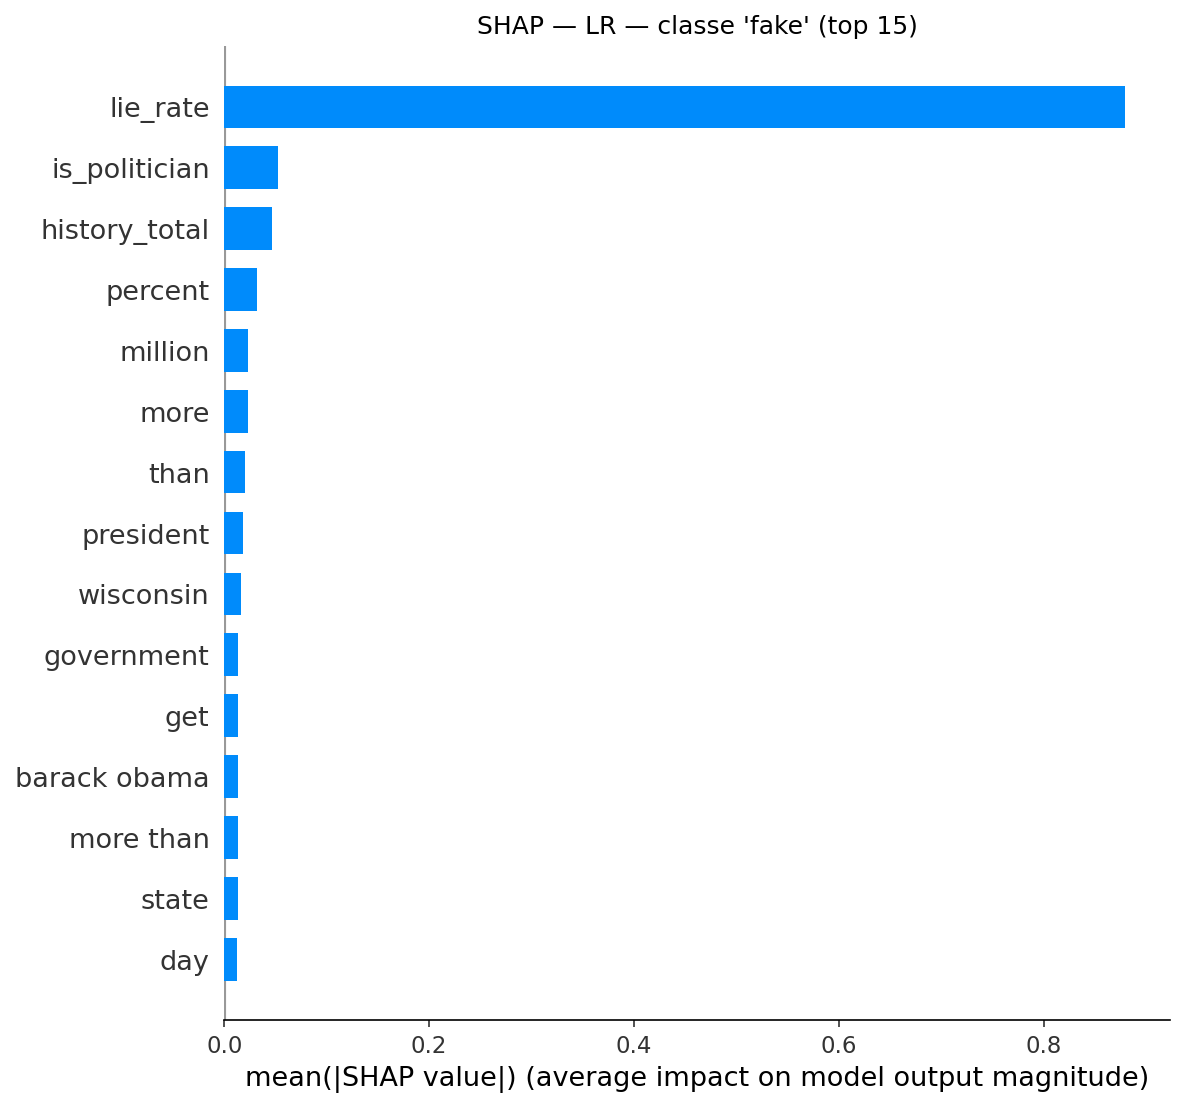


--- Classe : nuanced ---


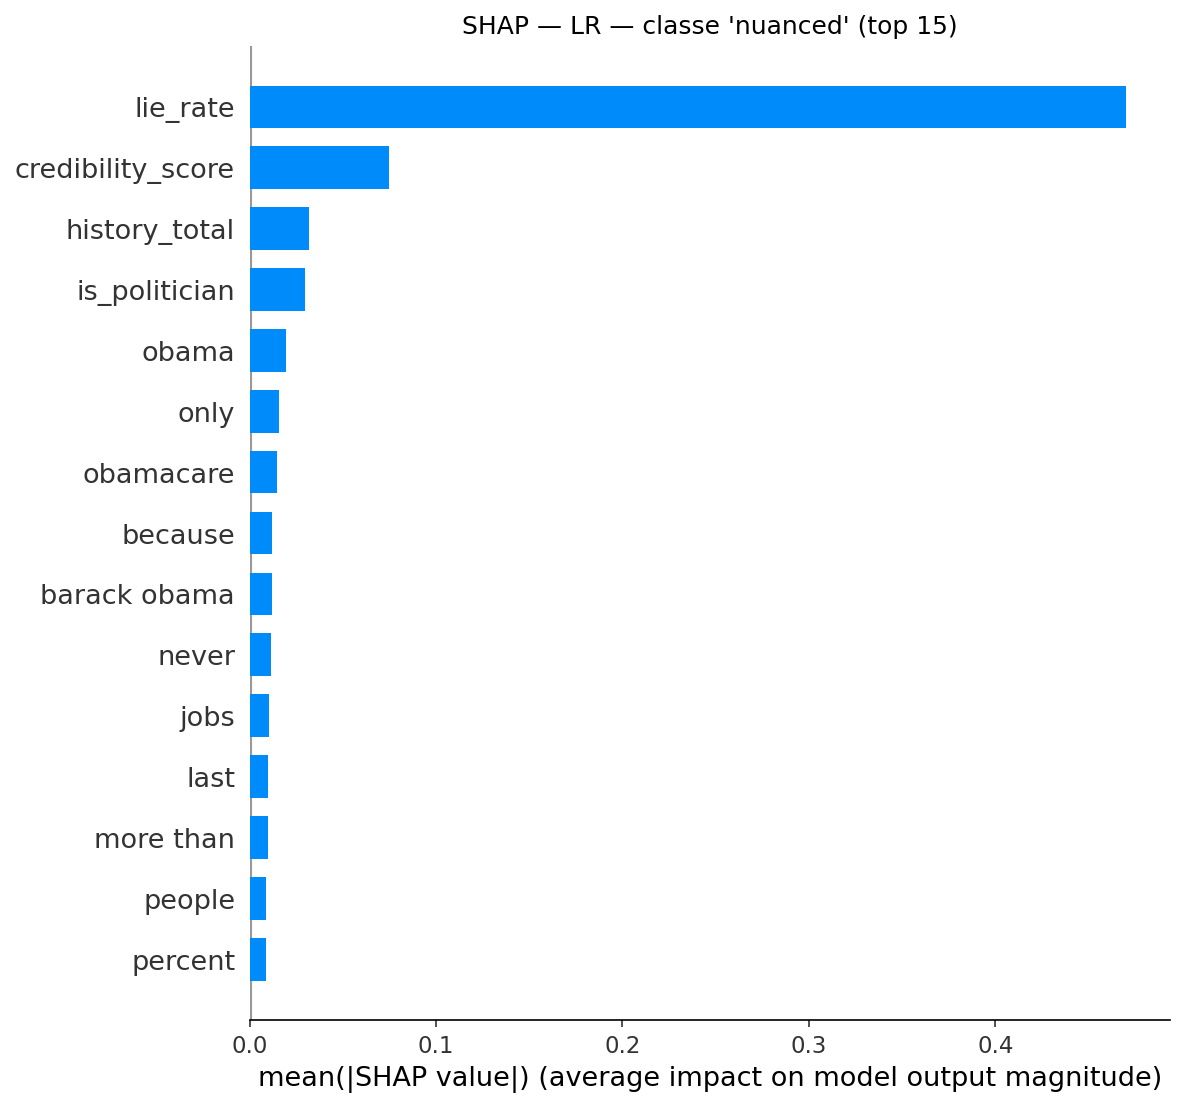


--- Classe : real ---


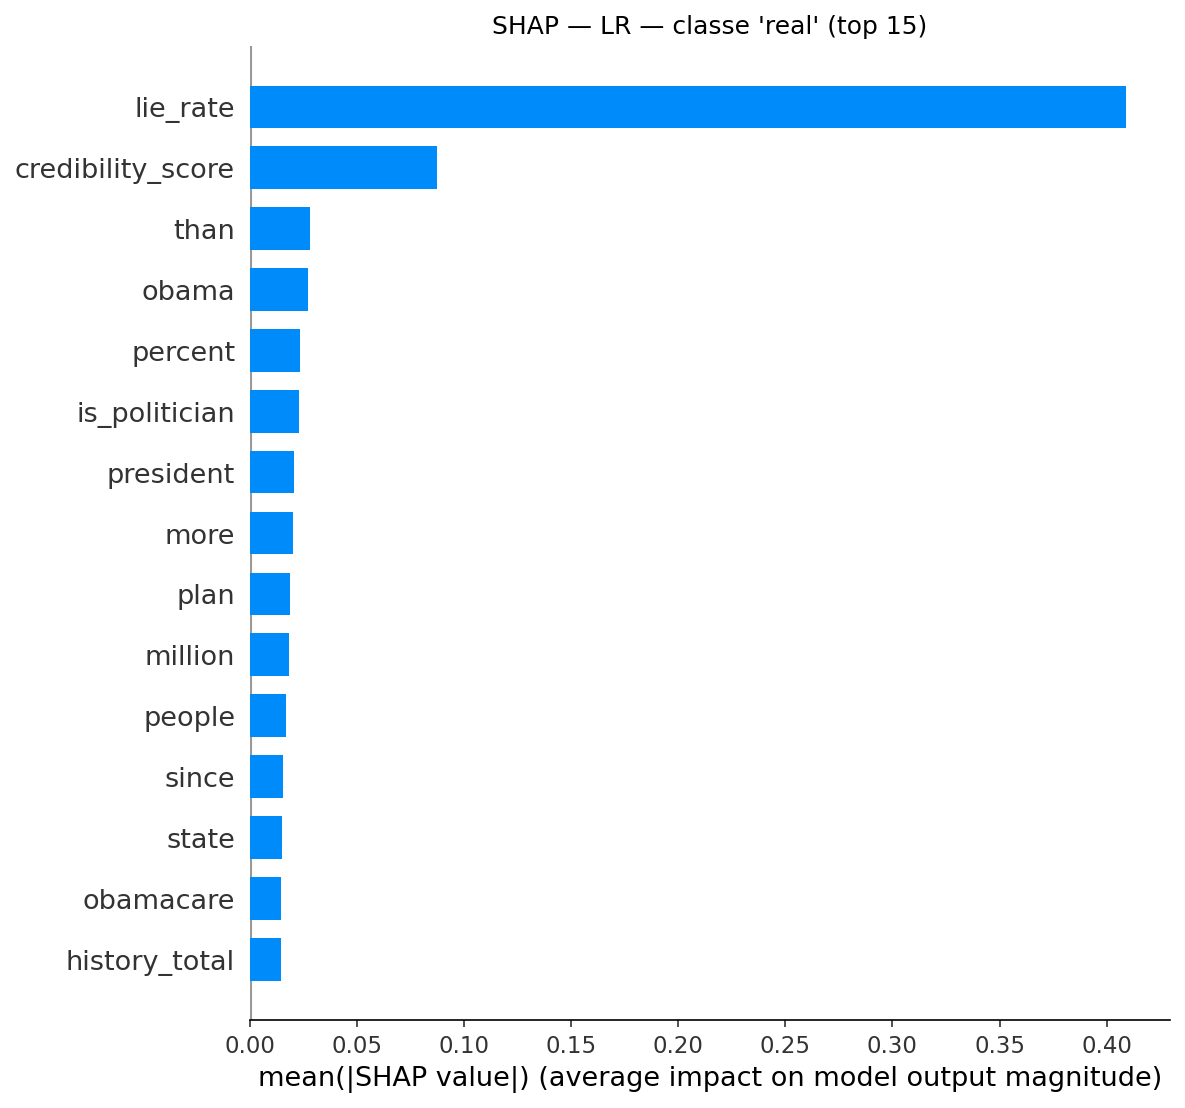

In [10]:
# Vérification de la shape
print(f"Shape shap_values : {shap_values_lr.values.shape}")
# Attendu : (200, n_features, 3) pour multiclasse

# Plot par classe séparément — beaucoup plus lisible
label_names = ["fake", "nuanced", "real"]

for i, label in enumerate(label_names):
    fig, ax = plt.subplots(figsize=(10, 7))
    shap.summary_plot(
        shap_values_lr.values[:, :, i],   # slice sur la classe i
        X_valid_dense[:200],
        feature_names=feature_names,
        max_display=15,
        show=False,
        plot_type="bar",                   # barplot = plus lisible que beeswarm ici
    )
    plt.title(f"SHAP — LR — classe '{label}' (top 15)")
    plt.tight_layout()
    path = f"outputs/figures/shap_logreg_{label}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Sauvegardé -> {path}")

# Affichage inline
from IPython.display import Image, display
for label in label_names:
    print(f"\n--- Classe : {label} ---")
    display(Image(f"outputs/figures/shap_logreg_{label}.png"))

In [11]:
X_train_dense_xgb = X_train.toarray() if hasattr(X_train, "toarray") else X_train
X_valid_dense_xgb = X_valid.toarray() if hasattr(X_valid, "toarray") else X_valid

explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb(X_valid_dense_xgb[:200])
print(f"Valeurs non-nulles : {np.count_nonzero(shap_values_xgb.values)}")


Valeurs non-nulles : 460800


Shape shap_values XGBoost : (200, 9053, 3)
Sauvegardé -> outputs/figures/shap_xgboost_fake.png
Sauvegardé -> outputs/figures/shap_xgboost_nuanced.png
Sauvegardé -> outputs/figures/shap_xgboost_real.png

--- Classe : fake ---


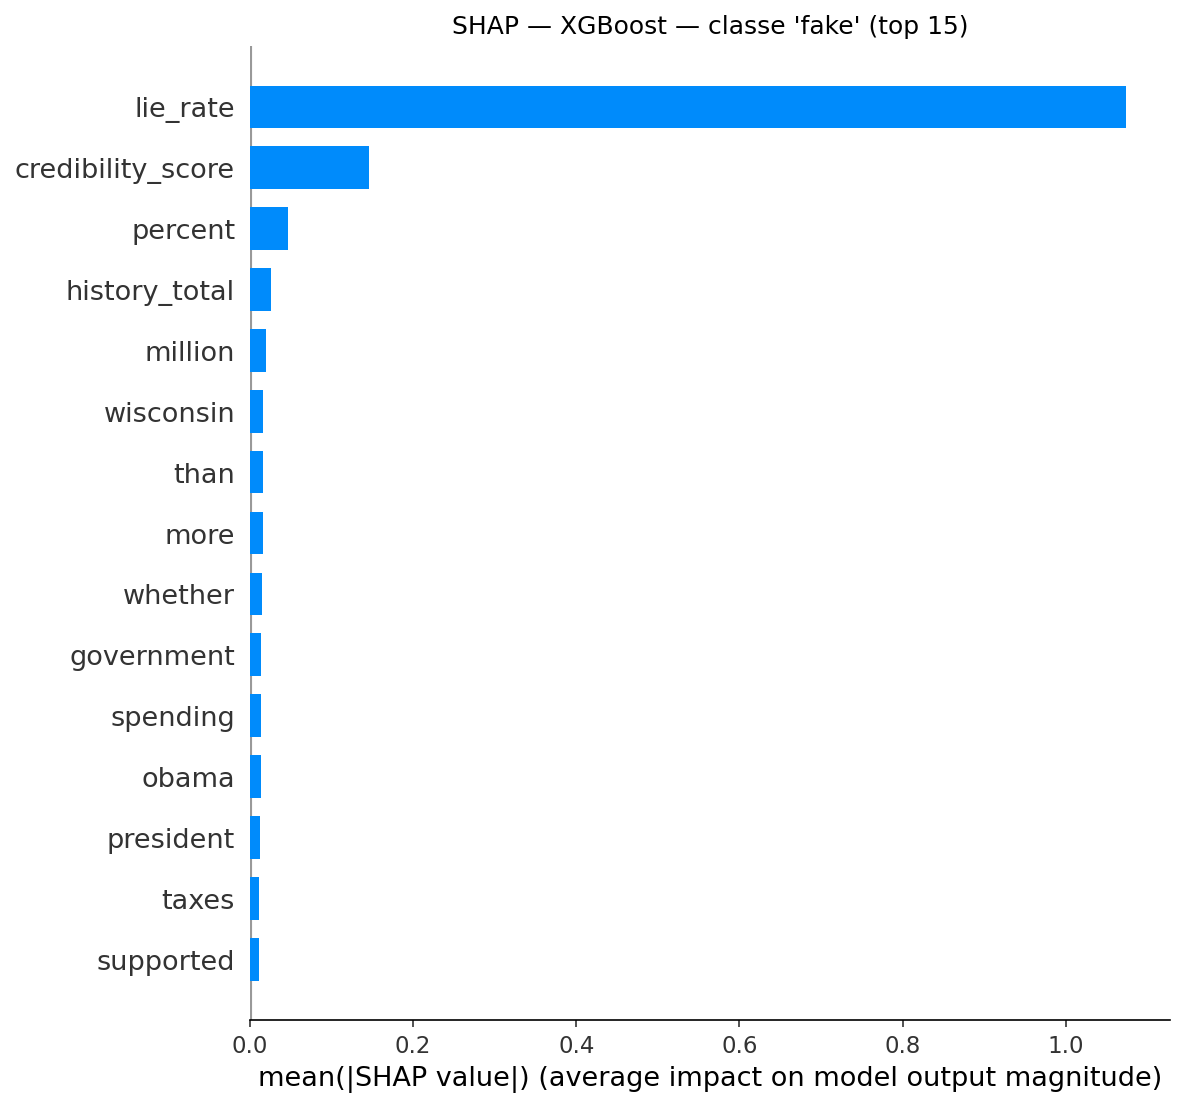


--- Classe : nuanced ---


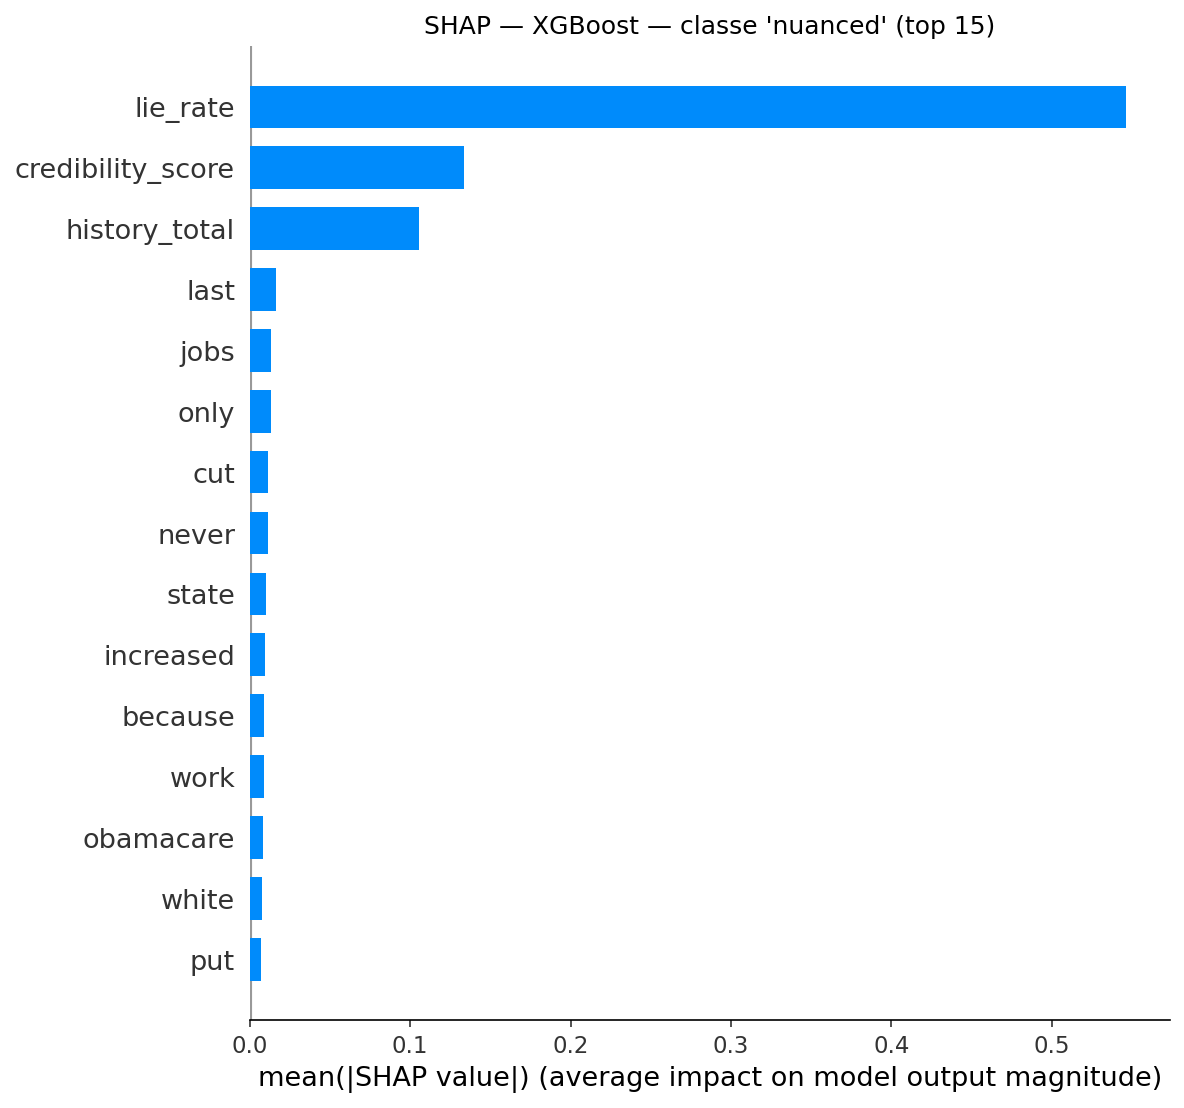


--- Classe : real ---


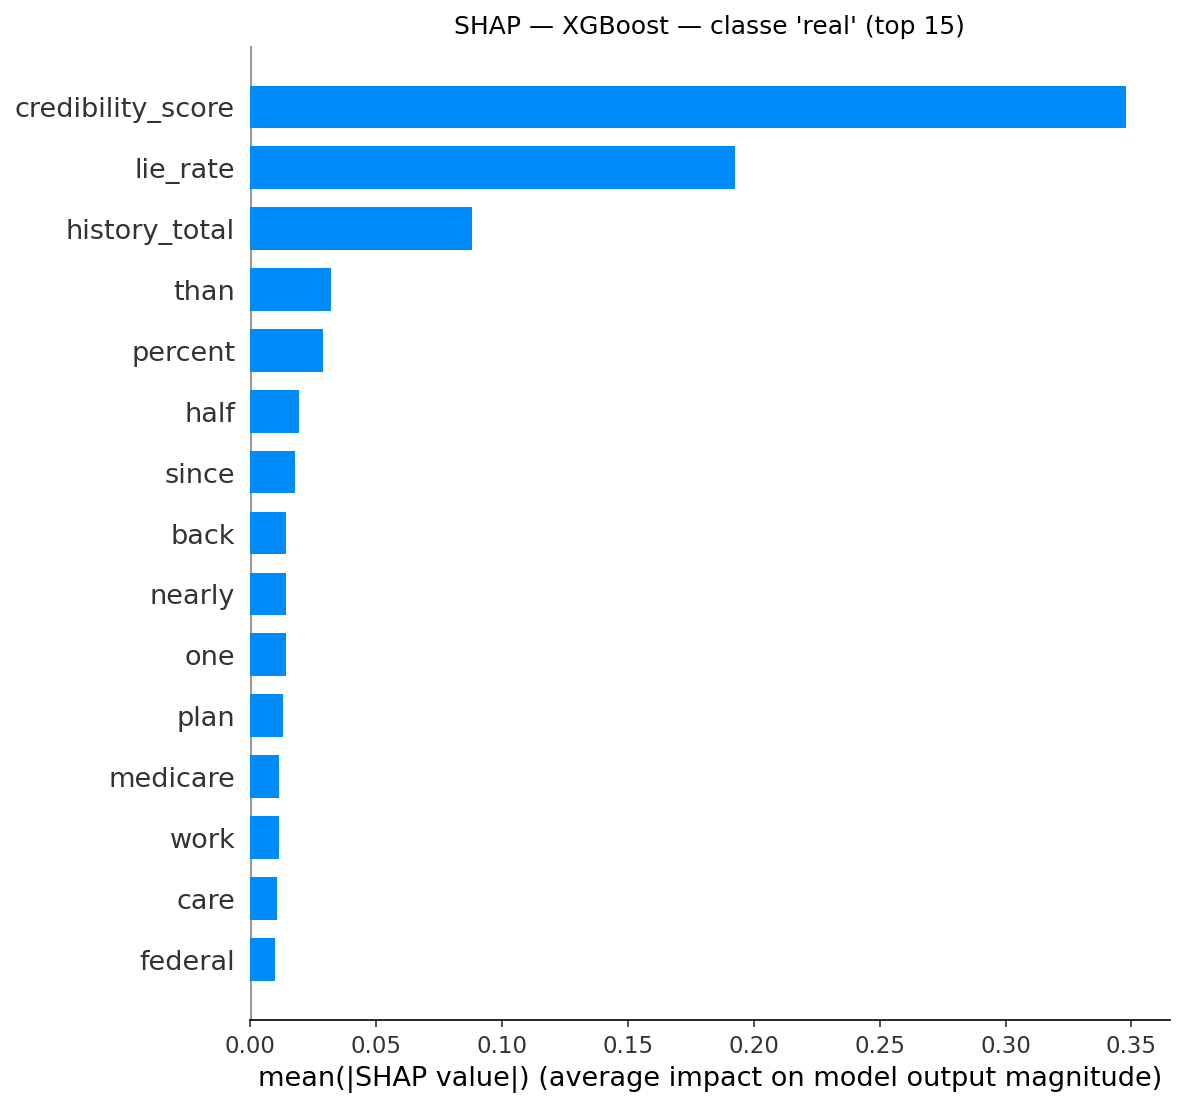

In [12]:
# SHAP XGBoost — par classe
X_train_dense_xgb = X_train.toarray() if hasattr(X_train, "toarray") else X_train
X_valid_dense_xgb = X_valid.toarray() if hasattr(X_valid, "toarray") else X_valid

explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb(X_valid_dense_xgb[:200])
print(f"Shape shap_values XGBoost : {shap_values_xgb.values.shape}")

label_names = ["fake", "nuanced", "real"]

for i, label in enumerate(label_names):
    fig, ax = plt.subplots(figsize=(10, 7))
    shap.summary_plot(
        shap_values_xgb.values[:, :, i],
        X_valid_dense_xgb[:200],
        feature_names=feature_names,
        max_display=15,
        show=False,
        plot_type="bar",
    )
    plt.title(f"SHAP — XGBoost — classe '{label}' (top 15)")
    plt.tight_layout()
    path = f"outputs/figures/shap_xgboost_{label}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Sauvegardé -> {path}")

from IPython.display import Image, display
for label in label_names:
    print(f"\n--- Classe : {label} ---")
    display(Image(f"outputs/figures/shap_xgboost_{label}.png"))

**Ce qu'on cherche dans les plots SHAP** :
- Les features textuelles (mots) qui poussent vers `fake` : exagérations,
  superlatifs, chiffres non vérifiables ?
- Le rôle du `credibility_score` : contribue-t-il fortement à la prédiction ?
  Si oui, le modèle juge autant le speaker que la déclaration.
- Des noms propres (speakers) dans les top features → sur-apprentissage à signaler.

### Analyse des résultats SHAP — Logistic Regression & XGBoost

#### 1. La dominance écrasante des métadonnées

Le résultat le plus frappant est commun aux deux modèles et aux 3 classes :
`lie_rate` et `credibility_score` dominent massivement toutes les autres features,
avec un score SHAP 5 à 50 fois supérieur aux features textuelles.

Concrètement, cela signifie que les deux modèles prédisent la véracité d'une
déclaration en se basant principalement sur **qui parle** (son historique PolitiFact)
plutôt que sur **ce qui est dit** (le contenu textuel).

Une nuance intéressante entre les deux modèles :
- La LR utilise `lie_rate` comme feature quasi-exclusive pour `fake` et `nuanced`
- XGBoost distribue mieux l'importance : pour `real`, `credibility_score` passe
  devant `lie_rate`, ce qui suggère que XGBoost capte mieux la distinction entre
  "quelqu'un qui dit généralement vrai" vs "quelqu'un qui ment rarement"

#### 2. Le biais speaker confirmé

`obama` et `barack obama` apparaissent dans les top features pour LR sur les classes
`real` et `nuanced`. Ce n'est pas anodin : Barack Obama est le speaker le plus
représenté du dataset avec 488 déclarations, et son historique PolitiFact est
majoritairement positif.

Le modèle a donc appris une association directe entre la présence du nom "obama"
dans le texte et un label `real` ou `nuanced` — indépendamment du contenu
de la déclaration. C'est un **biais de speaker** problématique : une déclaration
fausse attribuée à Obama serait probablement mal classifiée.

XGBoost est moins affecté par ce biais : "obama" apparaît dans les features `fake`
(position 12) avec un score très faible, ce qui montre que le gradient boosting
généralise mieux que la LR sur ce point.

#### 3. Les features textuelles discriminantes

Malgré la domination des métadonnées, quelques mots ressortent de façon cohérente :

**Pour la classe `fake`** : `percent`, `million`, `more than`, `government`, `spending`
Ces mots caractérisent les déclarations avec des chiffres précis et des affirmations
quantifiées — souvent utilisées dans les exagérations politiques. Le bigramme
`more than` est particulièrement intéressant : il indique une comparaison qui peut
facilement être manipulée.

**Pour la classe `real`** : `plan`, `since`, `nearly`, `half`, `medicare`, `federal`
Ces mots évoquent un vocabulaire plus factuel et institutionnel, cohérent avec
des déclarations vérifiables sur des politiques publiques.

**Pour la classe `nuanced`** : `only`, `never`, `because`, `cut`, `increased`
Ce sont des mots de nuance et de causalité — logique pour des déclarations
partiellement vraies qui nécessitent du contexte pour être jugées.

#### 4. Implication pour la généralisation (domain shift)

Cette analyse SHAP révèle un problème structurel pour l'évaluation out-of-domain :
le BuzzFeed dataset ne contient **pas de métadonnées PolitiFact** sur les speakers.

Lorsqu'on testera nos modèles sur BuzzFeed, `lie_rate` et `credibility_score`
seront à zéro pour tous les exemples — privant les modèles de leur feature
la plus importante. On anticipe donc une chute significative des performances,
qui ne reflétera pas une faiblesse du modèle en soi, mais une incompatibilité
structurelle entre les deux datasets.

C'est précisément ce que le domain shift analysis devra documenter.

## 7. Analyse des erreurs

In [13]:
# Analyse sur le meilleur modèle classique (adapter selon tes résultats)
errors_df = analyze_errors(
    df=test.reset_index(drop=True),
    y_true=y_test,
    y_pred=y_pred_lr_test,   # changer ici si LR n'est pas le meilleur
    n_examples=15
)


=== Analyse des erreurs : 586 / 1267 (46.3%) ===

Types d'erreurs (vrai -> prédit) :
label_true  label_pred
fake        nuanced        52
            real           54
nuanced     fake           85
            real          185
real        fake           66
            nuanced       144

--- 15 exemples d'erreurs ---

  Texte    : Building a wall on the U.S.-Mexico border will take literally years....
  Speaker  : rick-perry (republican)
  Vrai     : real  |  Prédit : fake

  Texte    : Wisconsin is on pace to double the number of layoffs this year....
  Speaker  : katrina-shankland (democrat)
  Vrai     : fake  |  Prédit : nuanced

  Texte    : Over the past five years the federal government has paid out $601 million in retirement and disabili...
  Speaker  : brendan-doherty (republican)
  Vrai     : real  |  Prédit : fake

  Texte    : Says that Tennessee law requires that schools receive half of proceeds -- $31 million per year -- fr...
  Speaker  : stand-children-tennessee (none)


**Questions à explorer sur les erreurs** :
- Y a-t-il des speakers sur-représentés dans les erreurs ?
- Les erreurs sur `nuanced` sont-elles systématiques dans un sens (→ fake ou → real) ?
- Les erreurs concernent-elles des déclarations particulièrement courtes ou longues ?

## 8. Fine-tuning DistilBERT (Apple Silicon MPS)

**Temps estimé sur M4 Pro** : ~15-20 min pour 3 époques sur 10 240 exemples.

In [14]:
# Recharger les données complètes si nécessaire (BERT utilise statement brut)
train_full = pd.read_csv("data/processed/train_clean.csv")
valid_full = pd.read_csv("data/processed/valid_clean.csv")

trainer, bert_model = train_bert(
    train_df=train_full,
    valid_df=valid_full,
    model_name="distilbert-base-uncased",
    num_epochs=3,
    batch_size=32,       # réduire à 16 si mémoire insuffisante
    learning_rate=2e-5,
    save_dir="models/bert_finetuned",
    max_length=128,
)

Device : Apple MPS (Metal Performance Shaders)

Chargement : distilbert-base-uncased


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9328.35it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenisation...


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



Fine-tuning (3 époques, batch=32, device=mps)...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.039034,1.034555,0.447819,0.436816,0.438885
2,1.001719,1.025478,0.451713,0.440219,0.441196
3,0.901542,1.036173,0.468847,0.462884,0.463814


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.35it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.15it/s]



Modèle sauvegardé -> models/bert_finetuned


In [15]:
# Évaluation BERT sur le test set
from src.train import predict_bert

test_full = pd.read_csv("data/processed/test_clean.csv")
y_pred_bert, bert_probs = predict_bert(
    texts=test_full["statement"],
    save_dir="models/bert_finetuned"
)

results_bert = evaluate_model(y_test, y_pred_bert, "DistilBERT fine-tuné — test set")

plot_confusion_matrix(
    y_test, y_pred_bert,
    model_name="DistilBERT",
    save_path="outputs/figures/cm_bert.png"
)

Device : Apple MPS (Metal Performance Shaders)


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 16466.88it/s]



  DistilBERT fine-tuné — test set
  Accuracy    : 0.4672
  F1 macro    : 0.4526   ← métrique principale
  F1 weighted : 0.4598

  F1 par classe :
    fake       : 0.3667
    nuanced    : 0.4468
    real       : 0.5444

              precision    recall  f1-score   support

        fake       0.44      0.32      0.37       341
     nuanced       0.46      0.44      0.45       477
        real       0.49      0.61      0.54       449

    accuracy                           0.47      1267
   macro avg       0.46      0.46      0.45      1267
weighted avg       0.46      0.47      0.46      1267

  Matrice sauvegardée -> outputs/figures/cm_bert.png


## 9. Comparaison finale des 4 modèles

In [16]:
all_results = [
    results_lr_test,
    results_rf_test,
    results_xgb_test,
    results_bert,
]

df_comparison = compare_models(all_results)
save_results(all_results, "outputs/results_indomain.csv")


=== Comparaison des modèles (triés par F1 macro) ===
                          model  accuracy  f1_macro  f1_weighted  f1_fake  f1_nuanced  f1_real
                  RF — test set    0.5651    0.5697       0.5616   0.6431      0.4874   0.5786
             XGBoost — test set    0.5556    0.5577       0.5504   0.6239      0.4824   0.5668
                  LR — test set    0.5375    0.5442       0.5338   0.6465      0.4705   0.5156
DistilBERT fine-tuné — test set    0.4672    0.4526       0.4598   0.3667      0.4468   0.5444
Résultats sauvegardés -> outputs/results_indomain.csv


In [17]:
# Visualisation comparative
import plotly.express as px

fig = px.bar(
    df_comparison,
    x="model", y=["accuracy", "f1_macro", "f1_fake", "f1_nuanced", "f1_real"],
    barmode="group",
    title="Comparaison des modèles — test set in-domain (LIAR)",
    labels={"value": "Score", "variable": "Métrique"},
)
fig.update_layout(xaxis_title="Modèle", yaxis_range=[0, 1])
fig.show()

**Résultats attendus (ordre de grandeur sur LIAR 3 classes)** :
- Logistic Regression + TF-IDF + meta : accuracy ~52-58%, F1 macro ~50-55%
- Random Forest                        : accuracy ~50-55%, F1 macro ~48-53%
- XGBoost                              : accuracy ~54-60%, F1 macro ~52-57%
- DistilBERT fine-tuné                 : accuracy ~60-66%, F1 macro ~58-64%

Ces scores paraissent faibles mais sont cohérents avec la littérature sur LIAR
en classification 3 classes. **Ce n'est pas grave** — l'évaluation porte sur
la rigueur de l'analyse, pas sur l'obtention d'un score élevé.

---
**Prochaine étape** : notebook `04_generalization.ipynb` — évaluation
out-of-domain sur BuzzFeed et analyse du domain shift.